INSTALL RDKIT AND IMPORT DESIRED LIBRARIES

In [1]:
!pip install rdkit
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, MACCSkeys, AllChem
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 25.2 MB/s eta 0:00:00


In [ ]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.warning')

LOAD DATA AND VALIDATE


In [2]:
df = pd.read_csv('/content/train.csv')
df.shape

(7697, 3)

In [3]:
df['Label'].value_counts()
df.head(5)

,Molecule_ID,SMILES,Label
0,NCGC00254052-01,CC(C)[C@H](SC(C)=O)C(=O)N[C@H]1CC2=C(C=CC=C2)[...,0
1,NCGC00256473-01,O=S1(=O)CC=CC1,0
2,NCGC00024643-03,CC(C(O)C1=CC=C(O)C=C1)N2CCC(CC3=CC=CC=C3)CC2,0
3,NCGC00016309-02,NC1=CC=C(C=C1)S(=O)(=O)NC2=NC=CS2,0
4,NCGC00164127-03,CC(C)(C)CC(C)(C)C1=CC=C(O)C=C1,1


Convert SMILES to RDKit molecules & validate

In [4]:
def validate_smiles(smiles):
    """Convert SMILES to RDKit Mol, return None if invalid"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol)
        return mol
    except:
        return None

# Apply validation
df['mol'] = df['SMILES'].apply(validate_smiles)

# Remove invalid molecules
df = df.dropna(subset=['mol']).reset_index(drop=True)

print(f"\n Valid training molecules: {len(df):,}")

[05:30:13] Explicit valence for atom # 2 Cl, 1, is greater than permitted
[05:30:14] Explicit valence for atom # 0 Cl, 1, is greater than permitted
[05:30:14] WARNING: not removing hydrogen atom without neighbors



 Valid training molecules: 7,695


Convert features to MACCS and Morgan Fingerprints

In [5]:
def generate_toxicity_features(mol):
    morgan_fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    maccs_fp = MACCSkeys.GenMACCSKeys(mol)

    # B. PHYSICOCHEMICAL DESCRIPTORS (ADME/toxicity factors)
    descriptors = np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol),
        rdMolDescriptors.CalcNumRings(mol),
        Descriptors.FractionCSP3(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
        Descriptors.NumAromaticRings(mol)
    ])

    # Combine: [Morgan 2048] + [MACCS 166] + [Descriptors 10] = 2224 features
    features = np.concatenate([np.array(morgan_fp), np.array(maccs_fp), descriptors])
    return features

# Generate features for train/test
X = np.array([generate_toxicity_features(mol) for mol in df['mol']])
y = df['Label'].values


Streaming output truncated to the last 5000 lines.
[05:30:25] DEPRECATION WARNING: please use MorganGenerator
[05:30:25] DEPRECATION WARNING: please use MorganGenerator
[05:30:25] DEPRECATION WARNING: please use MorganGenerator
[05:30:25] DEPRECATION WARNING: please use MorganGenerator
[05:30:25] DEPRECATION WARNING: please use MorganGenerator
[05:30:25] DEPRECATION WARNING: please use MorganGenerator
[05:30:25] DEPRECATION WARNING: please use MorganGenerator
[05:30:25] DEPRECATION WARNING: please use MorganGenerator
[05:30:25] DEPRECATION WARNING: please use MorganGenerator
[05:30:25] DEPRECATION WARNING: please use MorganGenerator
[05:30:25] DEPRECATION WARNING: please use MorganGenerator
[05:30:25] DEPRECATION WARNING: please use MorganGenerator
[05:30:25] DEPRECATION WARNING: please use MorganGenerator
[05:30:25] DEPRECATION WARNING: please use MorganGenerator
[05:30:25] DEPRECATION WARNING: please use MorganGenerator
[05:30:25] DEPRECATION WARNING: please use MorganGenerator
[05:3

Split dataset into train and test

In [6]:
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

# Handle class imbalance with SMOTE#to make distribution even
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"After SMOTE balancing: {np.bincount(y_train_bal)}")



Train set: 6156 samples
Validation set: 1539 samples
After SMOTE balancing: [5406 5406]


APPLY RANDOM FOREST

In [7]:
from sklearn.metrics import accuracy_score
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_bal, y_train_bal)

# Validation predictions
y_val_pred = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]

val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")

print("\n VALIDATION RESULTS")
print(classification_report(y_val, y_val_pred))
print(f" AUC-ROC: {roc_auc_score(y_val, y_val_proba):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

# Feature importance (top 10)
importances = model.feature_importances_
top_features = np.argsort(importances)[-10:]
print(f"\n Top 10 important features (Morgan bit indices): {top_features}")


Validation Accuracy: 0.9058

 VALIDATION RESULTS
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1352
           1       0.67      0.44      0.53       187

    accuracy                           0.91      1539
   macro avg       0.80      0.70      0.74      1539
weighted avg       0.90      0.91      0.90      1539

 AUC-ROC: 0.776

Confusion Matrix:
[[1312   40]
 [ 105   82]]

 Top 10 important features (Morgan bit indices): [2209 2173 2200 2221 1750 1313 2223 2175 1873 2193]


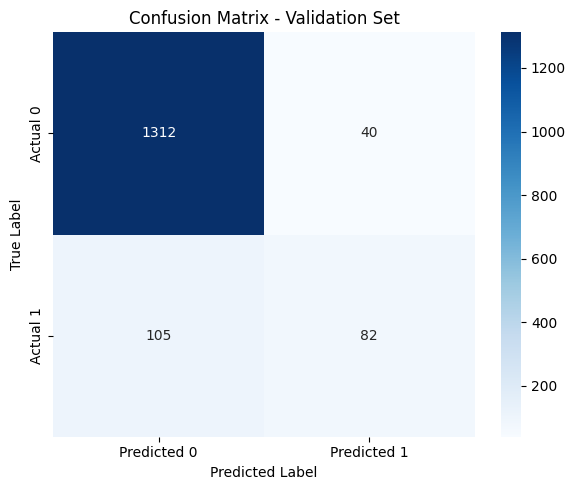

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Validation Set')
plt.tight_layout()
plt.show()


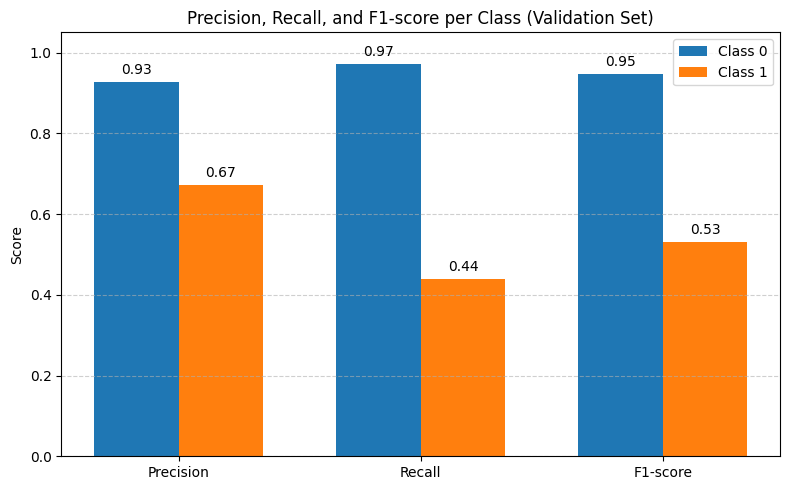

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Get classification report as a dictionary
report = classification_report(y_val, y_val_pred, output_dict=True)

# Classes and metrics
classes = ['0', '1']   # binary classification
metrics = ['precision', 'recall', 'f1-score']

# Extract metric values
scores = np.array([
    [report[cls][metric] for metric in metrics]
    for cls in classes
])

# Plot settings
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

# Bars for each class
plt.bar(x - width/2, scores[0], width, label='Class 0')
plt.bar(x + width/2, scores[1], width, label='Class 1')

# Labels and formatting
plt.xticks(x, ['Precision', 'Recall', 'F1-score'])
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.title('Precision, Recall, and F1-score per Class (Validation Set)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate bars
for i in range(scores.shape[0]):
    for j in range(scores.shape[1]):
        plt.text(
            x[j] + (-width/2 if i == 0 else width/2),
            scores[i, j] + 0.02,
            f"{scores[i, j]:.2f}",
            ha='center',
            fontsize=10
        )

plt.tight_layout()
plt.show()


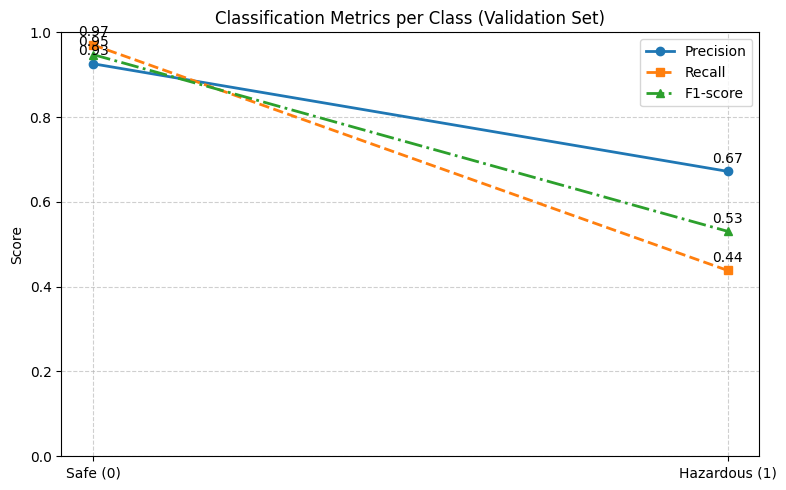

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Get classification report
report = classification_report(y_val, y_val_pred, output_dict=True)

# Classes (x-axis)
classes = ['Safe (0)', 'Hazardous (1)']
x = np.arange(len(classes))

# Metrics per class
precision = [report['0']['precision'], report['1']['precision']]
recall    = [report['0']['recall'],    report['1']['recall']]
f1_score  = [report['0']['f1-score'],  report['1']['f1-score']]

# Plot
plt.figure(figsize=(8, 5))

plt.plot(x, precision, marker='o', linewidth=2, label='Precision')
plt.plot(x, recall, marker='s', linestyle='--', linewidth=2, label='Recall')
plt.plot(x, f1_score, marker='^', linestyle='-.', linewidth=2, label='F1-score')

# Formatting
plt.xticks(x, classes)
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.title('Classification Metrics per Class (Validation Set)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate values
for i in range(len(x)):
    plt.text(x[i], precision[i] + 0.02, f"{precision[i]:.2f}", ha='center')
    plt.text(x[i], recall[i] + 0.02, f"{recall[i]:.2f}", ha='center')
    plt.text(x[i], f1_score[i] + 0.02, f"{f1_score[i]:.2f}", ha='center')

plt.tight_layout()
plt.show()


In [12]:
from joblib import dump, load

# Save the trained model
dump(model, "model_13_B2.pt")

# Later, to load it back
loaded_model = load("model_13_B2.pt")
